# Beyond Awareness: Identifying the Drivers of Sustainable Practices Adoption Among Built Environment Professionals


# Contents

1. Introduction
   - Background
   - Research Problem
   - Project Objectives
   - Research Questions

2. Environment Setup
   - Import Required Libraries
   - Load Dataset

3. Data Preparation
   - Initial Data Inspection
   - Data Cleaning
   - Variable Overview
   - Missing Value Assessment
   - Final Dataset

4. Exploratory Data Analysis (EDA)
   - Age Distribution
   - Professional Discipline
   - Sustainability Policy Awareness
   - Sustainable Practice Adoption

5. Current Practices vs. Perceived Areas of Greatest Contribution
   - Current Sustainable Practices
   - Perceived Contribution Areas
   - Practice–Contribution Gap
   - Priority Areas for Capacity Building

6. Correlation Analysis
   - Correlation between Policy Awareness and Adoption
   - Correlation Matrix
   - Interpretation

7. Regression Modelling
   Model 1
   - Policy Awareness
   - Infrastructure
   - Years of Experience

   Model 2
   - Adding Climate Policy Familiarity

   Model 3
   - Adding Organisational Adoption

8. Model Diagnostics
   - Correlation Matrix
   - Heatmap
   - Variance Inflation Factor (VIF)

9. Model Comparison

10. Key Findings

11. Discussion

12. Limitations

13. Conclusion

# 1. Introduction

## Background
Sustainable urban development has become a global priority due to increasing environmental challenges, rapid urbanisation, and climate change. Built environment professionals, including architects, engineers, planners, surveyors, and construction practitioners, play an essential role in translating sustainability policies into practical implementation through planning, design, construction, and infrastructure management.

Although sustainability awareness has improved considerably within the profession, evidence suggests that awareness alone does not always translate into sustainable practice. Understanding the factors that influence implementation is therefore critical for strengthening sustainable urban development initiatives.

This project reproduces and extends a previous statistical analysis using Python, providing a transparent and reproducible workflow for investigating sustainable practice adoption among built environment professionals.

Beyond identifying the determinants of sustainable practice adoption, this analysis also explores implementation gaps across sustainability domains to identify priority areas for future professional development, institutional support, and policy intervention.

## Project Objectives
This study aims to:
- Identify the key factors influencing sustainable practice adoption.
- Evaluate the gap between current sustainable practices and perceived areas of greatest professional contribution.
- Identify priority areas for future professional training, institutional support, and policy intervention.
  
## Research Questions
1. What is the level of sustainability awareness among built environment professionals?

2. To what extent are sustainable practices currently adopted?

3. Which factors significantly predict sustainable practice adoption?

4. Where are the largest gaps between current practice and perceived contribution?

5. What implications do these findings have for sustainable urban development policy and professional practice?

# 2. Environment Setup


In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

In [91]:
df = pd.read_csv(r"C:\Users\Ayofex Staff\Downloads\CleanData_for_SPSS.xlsx - DATA.csv")

# 3. Data Preparation

In [92]:
df.shape

(969, 50)

In [93]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 969 entries, 0 to 968
Data columns (total 50 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0    AgeGroup                                  147 non-null    str    
 1   Gender                                     147 non-null    str    
 2   YearsExperience                            147 non-null    str    
 3   Discipline                                 147 non-null    str    
 4   PolicyAwareness_NG                         147 non-null    str    
 5   PolicyAwareness_NG_Code                    147 non-null    float64
 6   PolicyAwareness_Global                     147 non-null    str    
 7   PolicyAwareness_Global_Code                147 non-null    float64
 8   OrgAdoption                                147 non-null    str    
 9   OrgAdoption_Code                           147 non-null    float64
 10  PersonalAdoption                     

In [94]:
df.isnull().sum()


 AgeGroup                                    822
Gender                                       822
YearsExperience                              822
Discipline                                   822
PolicyAwareness_NG                           822
PolicyAwareness_NG_Code                      822
PolicyAwareness_Global                       822
PolicyAwareness_Global_Code                  822
OrgAdoption                                  822
OrgAdoption_Code                             822
PersonalAdoption                             822
PersonalAdoption_Code                        822
Sustainable_pratice_implemented              822
Adopt_Waste                                    0
Adopt_Water                                    0
Adopt_Energy                                   0
Adopt_GreenInfra                               0
Adopt_ClimateDesign                            0
AdoptionScore                                  0
Infrastructure_reliability                   822
Infra_Water         

In [95]:
df.iloc[:, 45].head(10)


0    0
1    0
2    0
3    1
4    0
5    0
6    0
7    1
8    0
9    0
Name: Contrib_Water, dtype: int64

In [96]:
df.iloc[:, 45].unique()

array([0, 1])

In [97]:
df.tail()


,AgeGroup,Gender,YearsExperience,Discipline,PolicyAwareness_NG,PolicyAwareness_NG_Code,PolicyAwareness_Global,PolicyAwareness_Global_Code,OrgAdoption,OrgAdoption_Code,...,ChangeScore,Perceived_Professional_Impact_on_SUD,Perceived_Professional_Impact_on_SUD_code,Key_Contribution_Areas,Contrib_Waste,Contrib_Water,Contrib_Energy,Contrib_GreenInfra,Contrib_ClimateDesign,ContributionScore
964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,NaN,NaN,NaN,0,0,0,0,0,0
965,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,NaN,NaN,NaN,0,0,0,0,0,0
966,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,NaN,NaN,NaN,0,0,0,0,0,0
967,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,NaN,NaN,NaN,0,0,0,0,0,0
968,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,NaN,NaN,NaN,0,0,0,0,0,0


In [98]:
df.iloc[147:152]


,AgeGroup,Gender,YearsExperience,Discipline,PolicyAwareness_NG,PolicyAwareness_NG_Code,PolicyAwareness_Global,PolicyAwareness_Global_Code,OrgAdoption,OrgAdoption_Code,...,ChangeScore,Perceived_Professional_Impact_on_SUD,Perceived_Professional_Impact_on_SUD_code,Key_Contribution_Areas,Contrib_Waste,Contrib_Water,Contrib_Energy,Contrib_GreenInfra,Contrib_ClimateDesign,ContributionScore
147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,NaN,NaN,NaN,0,0,0,0,0,0
148,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,NaN,NaN,NaN,0,0,0,0,0,0
149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,NaN,NaN,NaN,0,0,0,0,0,0
150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,NaN,NaN,NaN,0,0,0,0,0,0
151,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,NaN,NaN,NaN,0,0,0,0,0,0


In [99]:
df = df.iloc[:147]


In [100]:
df.shape


(147, 50)

In [101]:
df.to_csv("CleanData_Final.csv", index=False)


## 4. Exploratory Data Analysis (EDA)

### Research Question

Who are the built environment professionals represented in this dataset?

### Why does this matter?

Understanding the demographic composition of respondents helps determine whether the sample is diverse and provides context for interpreting the findings.

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("CleanData_Final.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Check dimensions
print(df.shape)

(147, 50)


In [103]:
(df["AgeGroup"].value_counts(normalize=True) * 100).round(1)

AgeGroup
25 - 34         63.9
35 - 44         26.5
Under 25         5.4
45 - 54          3.4
55 and above     0.7
Name: proportion, dtype: float64



### Interpretation

The majority of respondents (94 out of 147) were between 25 and 34 years old, indicating that the sample is dominated by early-career professionals. This demographic profile is important because younger professionals may have different levels of awareness, adoption, and attitudes toward sustainable development compared to more experienced practitioners.

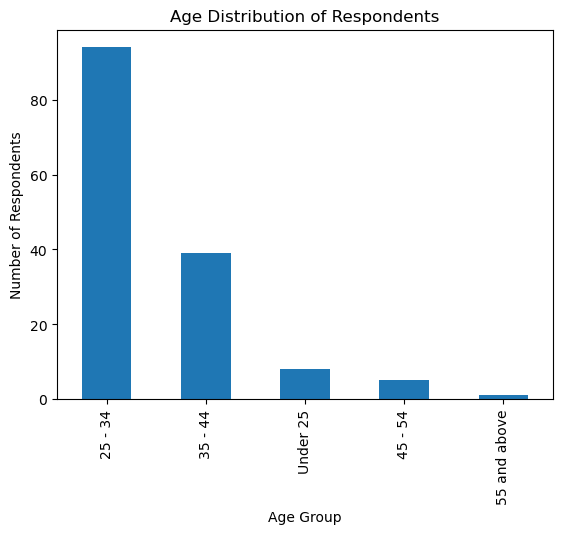

In [104]:
age_counts = df["AgeGroup"].value_counts()

age_counts.plot(kind="bar")

plt.title("Age Distribution of Respondents")
plt.xlabel("Age Group")
plt.ylabel("Number of Respondents")

plt.show()

### Research Question

What disciplines are represented in the study, and how balanced is the sample across the built environment professions?

### Why does this matter?

The discipline of a professional may influence their awareness, adoption, and contribution to sustainable development. Understanding the composition of the sample provides context for interpreting subsequent analyses.

In [105]:
discipline_counts = df["Discipline"].value_counts()

discipline_counts

Discipline
Architect                      29
Urban Planners                 29
Real Estate Professionals      27
Engineers                      23
Quantity Surveyors             15
Environmental Professionals    14
Project Managers                8
Builders                        2
Name: count, dtype: int64

In [106]:
(discipline_counts / len(df) * 100).round(1)

Discipline
Architect                      19.7
Urban Planners                 19.7
Real Estate Professionals      18.4
Engineers                      15.6
Quantity Surveyors             10.2
Environmental Professionals     9.5
Project Managers                5.4
Builders                        1.4
Name: count, dtype: float64

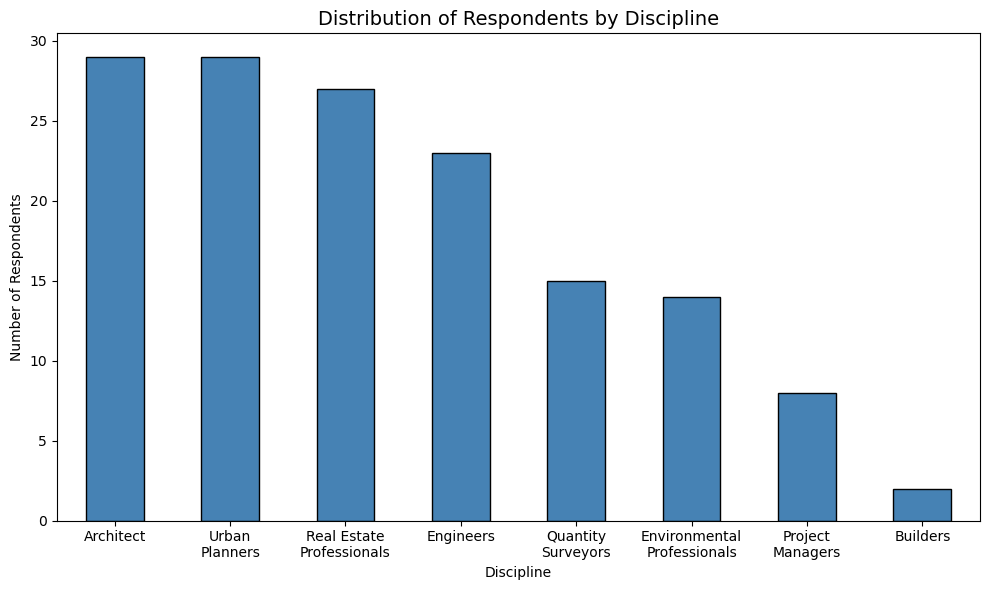

In [107]:
discipline_counts.index = [
    "Architect",
    "Urban\nPlanners",
    "Real Estate\nProfessionals",
    "Engineers",
    "Quantity\nSurveyors",
    "Environmental\nProfessionals",
    "Project\nManagers",
    "Builders"
]

plt.figure(figsize=(10,6))

discipline_counts.plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title("Distribution of Respondents by Discipline", fontsize=14)
plt.xlabel("Discipline")
plt.ylabel("Number of Respondents")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

## Research Question

How aware are built environment professionals of national and global sustainable development policies?

## Why is this important?

Awareness is often considered the first step toward implementation. However, awareness alone may not necessarily translate into sustainable practice. Understanding awareness levels provides the foundation for investigating whether knowledge leads to action.

In [108]:
(df["PolicyAwareness_NG"].value_counts(normalize=True) * 100).round(1)

PolicyAwareness_NG
Very familiar        46.9
Somewhat familiar    43.5
Not familiar          4.8
Expert level          4.8
Name: proportion, dtype: float64

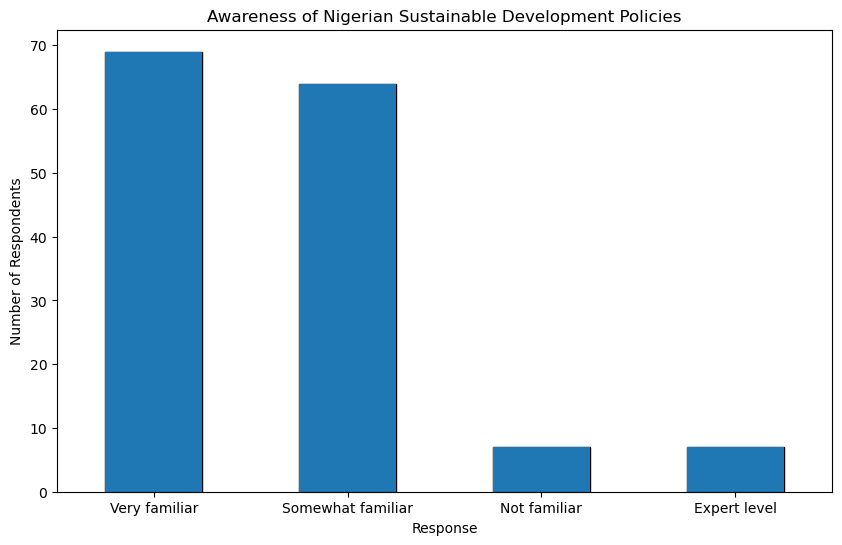

In [109]:
plt.figure(figsize=(10,6))

policy_ng.plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)
policy_ng = df["PolicyAwareness_NG"].value_counts()

policy_ng.plot(kind="bar")

plt.title("Awareness of Nigerian Sustainable Development Policies")
plt.xlabel("Response")
plt.ylabel("Number of Respondents")

plt.xticks(rotation=0)

plt.show()

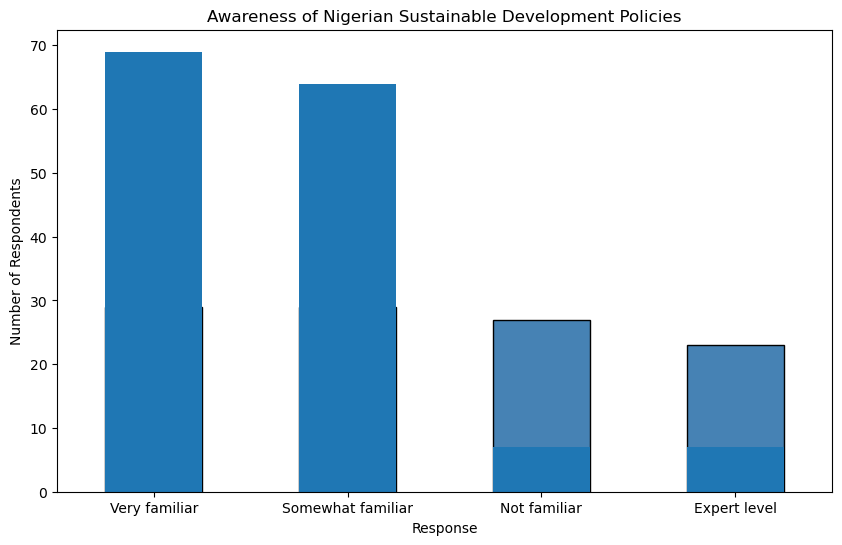

In [110]:
plt.figure(figsize=(10,6))

discipline_counts.plot(
    kind="bar",
    color="steelblue",
       edgecolor="black"
)
policy_ng = df["PolicyAwareness_NG"].value_counts()

policy_ng.plot(kind="bar")

plt.title("Awareness of Nigerian Sustainable Development Policies")
plt.xlabel("Response")
plt.ylabel("Number of Respondents")

plt.xticks(rotation=0)

plt.show()

### Interpretation

Awareness of Nigerian sustainable development policies was generally high among respondents. Approximately 95% reported being at least somewhat familiar with these policies, while fewer than 5% indicated no familiarity. This suggests that policy awareness is widespread among built environment professionals. Consequently, any gaps in sustainable practice are unlikely to be explained solely by a lack of awareness, indicating that other factors such as institutional support, infrastructure, or resource availability may play a more significant role.

# 5. Current Sustainable Practices  vs. Perceived Areas of Greatest Contribution

## Research Question

Which sustainable development practices are currently implemented most frequently by built environment professionals, and which areas do they believe offer the greatest opportunity to contribute to sustainable urban development?

## Why is this important?

Adoption reflects current professional behaviour, whereas perceived contribution reflects where professionals believe they can make the greatest impact. Comparing these dimensions helps identify implementation gaps and priority areas for policy intervention, capacity building, and investment.

In [111]:
contribution = (
    df[
        [
            "Contrib_Waste",
            "Contrib_Water",
            "Contrib_Energy",
            "Contrib_GreenInfra",
            "Contrib_ClimateDesign"
        ]
    ].mean() * 100
)

contribution.sort_values(ascending=False)


Contrib_GreenInfra       74.829932
Contrib_Waste            71.428571
Contrib_Energy           70.068027
Contrib_ClimateDesign    67.346939
Contrib_Water            53.061224
dtype: float64

In [112]:
practice = (
    df[
        [
            "Adopt_Waste",
            "Adopt_Water",
            "Adopt_Energy",
            "Adopt_GreenInfra",
            "Adopt_ClimateDesign"
        ]
    ].mean() * 100
)

practice

Adopt_Waste            72.789116
Adopt_Water            34.693878
Adopt_Energy           68.027211
Adopt_GreenInfra       46.938776
Adopt_ClimateDesign    43.537415
dtype: float64

In [113]:
contribution = (
    df[
        [
            "Contrib_Waste",
            "Contrib_Water",
            "Contrib_Energy",
            "Contrib_GreenInfra",
            "Contrib_ClimateDesign"
        ]
    ].mean() * 100
)

contribution


Contrib_Waste            71.428571
Contrib_Water            53.061224
Contrib_Energy           70.068027
Contrib_GreenInfra       74.829932
Contrib_ClimateDesign    67.346939
dtype: float64

In [114]:
comparison = pd.DataFrame({
    "Current Practice (%)": practice,
    "Perceived Contribution (%)": contribution
})

comparison

,Current Practice (%),Perceived Contribution (%)
Adopt_ClimateDesign,43.537415,NaN
Adopt_Energy,68.027211,NaN
Adopt_GreenInfra,46.938776,NaN
Adopt_Waste,72.789116,NaN
Adopt_Water,34.693878,NaN
Contrib_ClimateDesign,NaN,67.346939
Contrib_Energy,NaN,70.068027
Contrib_GreenInfra,NaN,74.829932
Contrib_Waste,NaN,71.428571
Contrib_Water,NaN,53.061224


In [115]:
practice.index = [
    "Waste",
    "Water",
    "Energy",
    "Green Infrastructure",
    "Climate Design"
]

contribution.index = [
    "Waste",
    "Water",
    "Energy",
    "Green Infrastructure",
    "Climate Design"
]

In [116]:
comparison = pd.DataFrame({
    "Current Practice (%)": practice,
    "Perceived Contribution (%)": contribution
})

comparison

,Current Practice (%),Perceived Contribution (%)
Waste,72.789116,71.428571
Water,34.693878,53.061224
Energy,68.027211,70.068027
Green Infrastructure,46.938776,74.829932
Climate Design,43.537415,67.346939


In [117]:
comparison["Gap (%)"] = (
    comparison["Perceived Contribution (%)"]
    - comparison["Current Practice (%)"]
)

comparison = comparison.sort_values(by="Gap (%)", ascending=False)

comparison

,Current Practice (%),Perceived Contribution (%),Gap (%)
Green Infrastructure,46.938776,74.829932,27.891156
Climate Design,43.537415,67.346939,23.809524
Water,34.693878,53.061224,18.367347
Energy,68.027211,70.068027,2.040816
Waste,72.789116,71.428571,-1.360544


## Interpretation

The comparison between current sustainable practices and perceived areas of greatest contribution reveals important implementation gaps.

Waste management (72.8%) and energy efficiency (68.0%) recorded the highest levels of current practice and showed relatively small gaps compared with perceived contribution, suggesting these practices are already well established among built environment professionals.

In contrast, green infrastructure exhibited the largest implementation gap (27.9 percentage points), followed by climate-responsive design (23.8 percentage points) and water conservation (18.4 percentage points). These findings indicate that professionals recognize substantial opportunities to contribute in these areas but may encounter barriers that limit implementation.

The pattern aligns with the regression analysis, which identified infrastructure as the strongest predictor of sustainable practice adoption. Together, these findings suggest that enhancing infrastructural capacity and institutional support may help professionals translate their knowledge and intentions into practice, particularly in areas with the largest implementation gaps.

# Adoption of Sustainable Practices

## Research Question

To what extent have built environment professionals adopted sustainable development practices in their professional activities?

## Why is this important?

Awareness of sustainability policies does not necessarily translate into implementation. Examining the adoption score provides insight into whether professionals are integrating sustainable practices into their work and establishes a baseline for investigating the factors influencing adoption.



In [118]:
df["AdoptionScore"].describe()

count    147.000000
mean       2.659864
std        1.246895
min        1.000000
25%        2.000000
50%        3.000000
75%        3.000000
max        5.000000
Name: AdoptionScore, dtype: float64

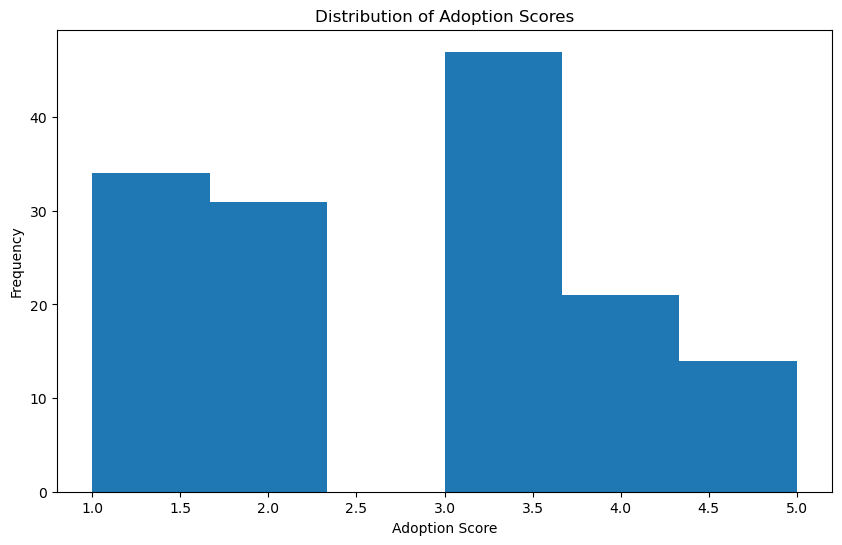

In [119]:
plt.figure(figsize=(10,6))

df["AdoptionScore"].plot(
    kind="hist",
    bins=6
)

plt.title("Distribution of Adoption Scores")
plt.xlabel("Adoption Score")
plt.ylabel("Frequency")

plt.show()

## Key Findings

- The average adoption score was **2.66 out of 5**, indicating a moderate level of sustainable practice adoption.
- Half of the respondents reported adoption scores of **3 or lower**.
- Approximately 75% of respondents scored **3 or below**, suggesting that high adoption levels are relatively uncommon.
- The distribution indicates that respondents generally cluster around low-to-moderate adoption levels rather than high adoption.

## Interpretation

Although respondents demonstrated a high level of awareness of sustainable development policies, the average adoption score suggests that implementation remains moderate. This indicates that knowledge alone may not be sufficient to encourage sustainable practices within the built environment sector. The observed gap between awareness and adoption suggests that other institutional, organizational, or infrastructural factors may influence professionals' ability to implement sustainable development practices.

## Transition to Next Analysis

The findings raise an important question:

**If awareness is high but adoption remains moderate, what factors are influencing sustainable practice adoption?**

The next section addresses this question by examining the relationship between policy awareness and adoption and subsequently identifying the strongest predictors of adoption through regression analysis.

In [120]:
y = df["AdoptionScore"]

In [121]:
# Dependent Variable
y = df["AdoptionScore"]

# Independent Variables
X = df[[
    "PolicyAwareness_NG_Code",
    "InfraIndex",
    "YearsExperience"
]]

In [144]:
X = sm.add_constant(X)

In [123]:
print(X.dtypes)

const                      float64
PolicyAwareness_NG_Code    float64
InfraIndex                   int64
YearsExperience                str
dtype: object


In [124]:
df["YearsExperience"].unique()

<StringArray>
['6 - 10 years', '3 - 5 years', '0 -2 years', '11 - 20 years',
 'Over 20 years']
Length: 5, dtype: str

In [125]:
experience_map = {
    "0 -2 years": 1,
    "3 - 5 years": 2,
    "6 - 10 years": 3,
    "11 - 20 years": 4,
    "Over 20 years": 5
}

df["YearsExperience_Code"] = df["YearsExperience"].map(experience_map)

In [126]:
df[["YearsExperience", "YearsExperience_Code"]].head(10)

,YearsExperience,YearsExperience_Code
0,6 - 10 years,3
1,3 - 5 years,2
2,3 - 5 years,2
3,3 - 5 years,2
4,3 - 5 years,2
5,3 - 5 years,2
6,3 - 5 years,2
7,3 - 5 years,2
8,3 - 5 years,2
9,3 - 5 years,2


In [127]:
X = df[[
    "PolicyAwareness_NG_Code",
    "InfraIndex",
    "YearsExperience_Code"
]]

X = sm.add_constant(X)

In [128]:
print(X.dtypes)

const                      float64
PolicyAwareness_NG_Code    float64
InfraIndex                   int64
YearsExperience_Code         int64
dtype: object


In [129]:
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          AdoptionScore   R-squared:                       0.244
Model:                            OLS   Adj. R-squared:                  0.228
Method:                 Least Squares   F-statistic:                     15.34
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           1.04e-08
Time:                        08:18:35   Log-Likelihood:                -220.01
No. Observations:                 147   AIC:                             448.0
Df Residuals:                     143   BIC:                             460.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

## Results

A multiple linear regression model was fitted to examine whether policy awareness, infrastructure, and years of professional experience predicted sustainable practice adoption.

The overall regression model was statistically significant (F = 15.34, p < 0.001), indicating that the selected predictors collectively explain variation in adoption scores.

The model explained approximately **24.4%** of the variance in sustainable practice adoption (R² = 0.244).

### Predictor Effects

- **Policy awareness** was a significant positive predictor of adoption (β = 0.392, p = 0.006).
- **Infrastructure** was also a significant positive predictor of adoption (β = 0.370, p < 0.001).
- **Years of professional experience** was not a statistically significant predictor (β = 0.090, p = 0.328).

### Interpretation

The findings suggest that both policy awareness and infrastructure contribute significantly to sustainable practice adoption among built environment professionals. However, years of professional experience does not appear to significantly influence adoption once awareness and infrastructure are considered. These results imply that improving institutional capacity and infrastructure may be as important as increasing policy awareness in promoting sustainable development practices.

### Priority Areas for Capacity Building

The comparison between current sustainable practices and perceived areas of contribution provides important guidance for professional development and policy interventions.

Green infrastructure demonstrated the largest implementation gap (27.9 percentage points), indicating that professionals recognise its importance but may lack sufficient opportunities, resources, or technical capacity to implement it consistently.

Similarly, climate-responsive design (23.8 percentage points) and water conservation (18.4 percentage points) also displayed substantial implementation gaps, suggesting considerable unrealised potential within these domains.

These findings indicate that future capacity-building initiatives, professional training programmes, and institutional investments should prioritise green infrastructure, climate-responsive design, and water conservation. Strengthening competencies and implementation support in these areas may enable professionals to translate sustainability knowledge into practical action more effectively.

Conversely, waste management and energy efficiency exhibited relatively small implementation gaps, suggesting these practices are comparatively mature and already well integrated into professional practice.

# 6. Correlation Analysis

## Research Question: Does Awareness Translate into Adoption?

Is there a relationship between awareness of Nigerian sustainable development policies and the adoption of sustainable practices among built environment professionals?

## Hypothesis

H₀ (Null Hypothesis):
There is no statistically significant relationship between policy awareness and adoption.

H₁ (Alternative Hypothesis):
There is a statistically significant positive relationship between policy awareness and adoption.

In [130]:
df[["PolicyAwareness_NG_Code", "AdoptionScore"]].head()


,PolicyAwareness_NG_Code,AdoptionScore
0,1.0,3
1,1.0,1
2,1.0,1
3,1.0,2
4,1.0,1


In [131]:
from scipy.stats import pearsonr


In [132]:
correlation, p_value = pearsonr(
    df["PolicyAwareness_NG_Code"],
    df["AdoptionScore"]
)

print(f"Correlation coefficient (r): {correlation:.3f}")
print(f"P-value: {p_value:.3f}")

Correlation coefficient (r): 0.263
P-value: 0.001


### Interpretation:
A Pearson correlation analysis revealed a weak positive relationship between awareness of Nigerian sustainable development policies and sustainable practice adoption (r = 0.263, p = 0.001). Although the relationship was statistically significant, its relatively small magnitude suggests that awareness alone is not a strong predictor of adoption. This finding indicates that while professionals who are more aware tend to report slightly higher levels of adoption, other factors are likely to play a more substantial role in influencing sustainable practices.

# 7. Regression Modelling

**Model 1**
  **- Policy Awareness**
   **- Infrastructure**
   **- Years of Experience**

## Research Question

Among the significant predictors identified in the previous regression model, which variable has the strongest influence on sustainable practice adoption?

## Why is this important?

The regression coefficients obtained previously are measured in different units and therefore cannot be directly compared. Standardizing the variables places all predictors on the same scale, allowing their relative importance to be evaluated.

In [133]:
from sklearn.preprocessing import StandardScaler

predictors = df[[
    "PolicyAwareness_NG_Code",
    "InfraIndex",
    "YearsExperience_Code"
]]

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(predictors),
    columns=predictors.columns
)

X_scaled = sm.add_constant(X_scaled)

model_std = sm.OLS(y, X_scaled).fit()

print(model_std.summary())

                            OLS Regression Results                            
Dep. Variable:          AdoptionScore   R-squared:                       0.244
Model:                            OLS   Adj. R-squared:                  0.228
Method:                 Least Squares   F-statistic:                     15.34
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           1.04e-08
Time:                        08:18:35   Log-Likelihood:                -220.01
No. Observations:                 147   AIC:                             448.0
Df Residuals:                     143   BIC:                             460.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

# Model 2 – Adding Climate Policy Familiarity

## Research Question

Does familiarity with climate policies improve the prediction of sustainable practice adoption beyond general policy awareness?

## Why is this important?

General awareness indicates whether professionals have heard about sustainability policies. Climate policy familiarity reflects a deeper understanding of policy objectives and implementation strategies. This model examines whether greater familiarity translates into higher levels of sustainable practice adoption.

## New Predictor

- ClimatePolicy_Familiarity_Code

## Objective

Compare Model 2 with Model 1 to determine whether climate policy familiarity improves the explanatory power of the regression model.

In [134]:
predictors2 = df[[
    "PolicyAwareness_NG_Code",
    "ClimatePolicy_Familiarity_Code",
    "InfraIndex",
    "YearsExperience_Code"
]]

In [135]:
scaler = StandardScaler()

X2 = pd.DataFrame(
    scaler.fit_transform(predictors2),
    columns=predictors2.columns
)

X2 = sm.add_constant(X2)

In [136]:
model2 = sm.OLS(y, X2).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:          AdoptionScore   R-squared:                       0.247
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     11.62
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           3.42e-08
Time:                        08:18:35   Log-Likelihood:                -219.70
No. Observations:                 147   AIC:                             449.4
Df Residuals:                     142   BIC:                             464.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

## Model 2 Interpretation

Model 2 examined whether adding climate policy familiarity improved the prediction of sustainable practice adoption.

The model explained **24.7%** of the variation in adoption scores (R² = 0.247), representing only a marginal improvement over Model 1 (R² = 0.244). Furthermore, the adjusted R² decreased slightly, suggesting that the additional predictor did not meaningfully improve the model.

Climate policy familiarity was **not a statistically significant predictor** of adoption (β = 0.082, p = 0.445). In contrast, infrastructure remained the strongest significant predictor (β = 0.499, p < 0.001), while policy awareness also remained significant (β = 0.224, p = 0.036). Years of professional experience continued to show no significant association with adoption.

These findings suggest that increasing familiarity with climate policies alone may not lead to greater adoption of sustainable practices once general policy awareness and infrastructural conditions are considered.

## Researcher's Reflection

Initially, I expected climate policy familiarity to improve the predictive performance of the model. However, adding this variable resulted in only a marginal increase in R² (0.244 to 0.247), while the adjusted R² decreased slightly. This suggests that climate policy familiarity provides little additional explanatory value beyond general policy awareness.

The persistence of infrastructure as the strongest predictor reinforces the hypothesis that implementation barriers may be more influential than knowledge barriers in determining sustainable practice adoption.

# Model 3 – The Role of Organizational Adoption

## Research Question

Does organizational adoption of sustainable development practices influence the adoption of sustainable practices by individual built environment professionals?

## Why is this important?

Individual professionals do not work in isolation. Their ability to implement sustainable practices may depend on the organizational environment in which they operate. Organizations that actively adopt sustainability may provide supportive leadership, policies, infrastructure, funding, and institutional culture that encourage professionals to implement sustainable practices in their daily work.

## Hypothesis

**H₀ (Null Hypothesis):**

Organizational adoption does not significantly predict individual sustainable practice adoption.

**H₁ (Alternative Hypothesis):**

Higher levels of organizational adoption are associated with higher levels of individual sustainable practice adoption.

In [137]:
predictors3 = df[[
    "PolicyAwareness_NG_Code",
    "InfraIndex",
    "YearsExperience_Code",
    "OrgAdoption_Code"
]]

In [138]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X3 = pd.DataFrame(
    scaler.fit_transform(predictors3),
    columns=predictors3.columns
)

X3 = sm.add_constant(X3)

In [139]:
model3 = sm.OLS(y, X3).fit()

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:          AdoptionScore   R-squared:                       0.255
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     12.14
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           1.64e-08
Time:                        08:18:35   Log-Likelihood:                -218.91
No. Observations:                 147   AIC:                             447.8
Df Residuals:                     142   BIC:                             462.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

## Model 3 Interpretation

Adding organizational adoption resulted in a modest increase in the model's explanatory power (R² = 0.255). However, organizational adoption was not a statistically significant predictor of sustainable practice adoption after accounting for policy awareness, infrastructure, and years of professional experience.

Infrastructure remained the strongest and most consistent predictor across all regression models (β = 0.466, p < 0.001). In contrast, the statistical significance of policy awareness weakened (p = 0.058), suggesting that part of its relationship with adoption may overlap with broader organizational or contextual factors.

These findings indicate that while organizational support may contribute to sustainable practice adoption, its independent effect was not statistically distinguishable in this model. Additional investigation into relationships among the predictors is warranted before extending the model further.

# 8. Model Diagnostics

## Research Question

Are the assumptions of the regression model reasonably satisfied, and are the predictors sufficiently independent of one another?

## Why is this important?

Regression analysis relies on several assumptions, including low multicollinearity among predictors and approximately normal residuals. Evaluating these assumptions increases confidence in the validity and interpretation of the regression results.

In [140]:
corr = df[[
    "PolicyAwareness_NG_Code",
    "InfraIndex",
    "YearsExperience_Code",
    "OrgAdoption_Code",
    "AdoptionScore"
]].corr()

corr


,PolicyAwareness_NG_Code,InfraIndex,YearsExperience_Code,OrgAdoption_Code,AdoptionScore
PolicyAwareness_NG_Code,1.000000,0.080340,0.277730,0.432534,0.262803
InfraIndex,0.080340,1.000000,0.112851,0.286225,0.431323
YearsExperience_Code,0.277730,0.112851,1.000000,0.133625,0.178634
OrgAdoption_Code,0.432534,0.286225,0.133625,1.000000,0.308519
AdoptionScore,0.262803,0.431323,0.178634,0.308519,1.000000


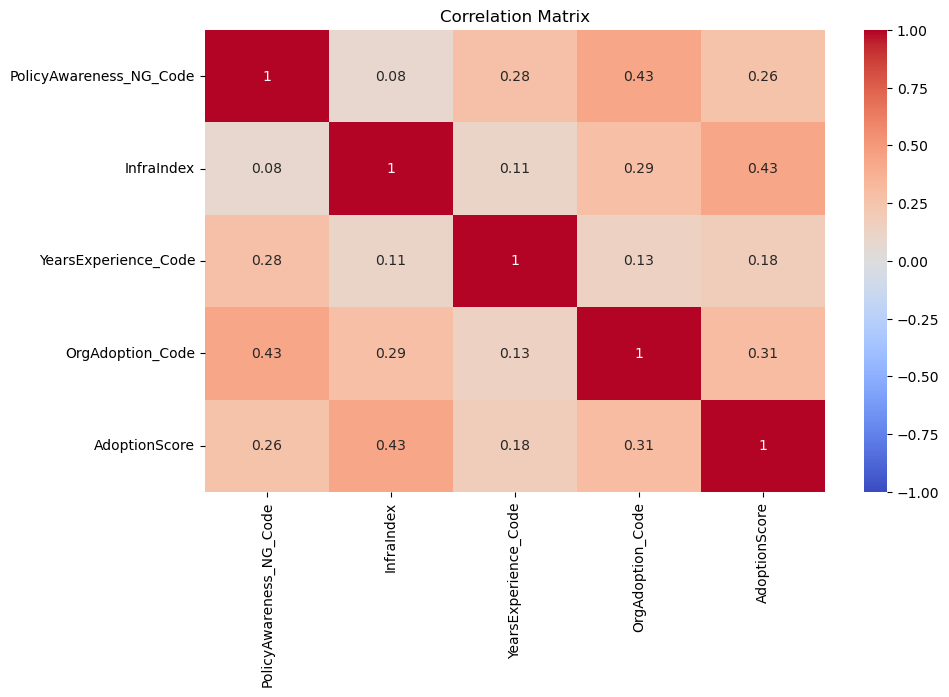

In [145]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix")

plt.show()

In [142]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [143]:
predictors = df[[
    "PolicyAwareness_NG_Code",
    "InfraIndex",
    "YearsExperience_Code",
    "OrgAdoption_Code"
]]

predictors = sm.add_constant(predictors)

vif = pd.DataFrame()

vif["Variable"] = predictors.columns

vif["VIF"] = [
    variance_inflation_factor(
        predictors.values,
        i
    )
    for i in range(predictors.shape[1])
]

vif

## Correlation Analysis Interpretation

The correlation matrix indicates that infrastructure exhibits the strongest positive relationship with sustainable practice adoption (r = 0.431), followed by organizational adoption (r = 0.309), policy awareness (r = 0.263), and years of professional experience (r = 0.179).

Interestingly, organizational adoption demonstrated a moderate positive correlation with adoption but was not statistically significant in the multiple regression model. This suggests that part of its relationship with adoption overlaps with other predictors, particularly infrastructure and policy awareness.

The relatively low correlations among the independent variables indicate that severe multicollinearity is unlikely. Consequently, the regression coefficients are likely to represent meaningful independent contributions of the predictors.

#### Reflection

*Initially, I expected climate policy familiarity and organizational adoption to improve the predictive performance of the regression model substantially. However, sequential modeling revealed that these variables added little explanatory power beyond policy awareness and infrastructure. This reinforced the importance of evaluating predictors systematically rather than assuming theoretical importance translates directly into statistical significance.*

# 9. Model Comparison
| Model   | Predictors                              |    R² | Adj. R² | Significant Predictors    | Key Insight                        |
| ------- | --------------------------------------- | ----: | ------: | ------------------------- | ---------------------------------- |
| Model 1 | Awareness + Infrastructure + Experience | 0.244 |   0.228 | Awareness, Infrastructure | Infrastructure strongest predictor |
| Model 2 | + Climate Familiarity                   | 0.247 |   0.225 | Awareness, Infrastructure | Climate familiarity adds little    |
| Model 3 | + Organizational Adoption               | 0.255 |   0.234 | Infrastructure            | Infrastructure remains dominant    |


# 10. Key Findings

The analysis revealed several important findings:

- Respondents demonstrated high levels of sustainability policy awareness.

- Sustainable practice adoption remained moderate despite this high awareness.

- Infrastructure consistently emerged as the strongest predictor of sustainable practice adoption.

- Years of professional experience did not significantly predict adoption.

- Climate policy familiarity and organisational adoption contributed little additional explanatory power once infrastructure and awareness were considered.

- Green infrastructure (27.9 percentage points), climate-responsive design (23.8 percentage points), and water conservation (18.4 percentage points) exhibited the largest gaps between current implementation and perceived contribution.

- These findings identify the areas where professionals believe they can make substantially greater contributions, suggesting priority areas for future training, institutional support, and policy investment.

- Waste management and energy efficiency showed relatively high implementation rates and comparatively small implementation gaps.

# 11. Discussion

The findings indicate that investments in infrastructure and institutional support should not be distributed uniformly across all sustainability domains. Instead, priority should be given to green infrastructure, climate-responsive design, and water conservation, where professionals reported the largest gaps between current implementation and perceived contribution.

These domains represent areas of substantial unrealised capacity and therefore provide the greatest opportunity for targeted interventions, professional development, and policy support.

# 12. Limitations

Several limitations should be considered when interpreting these findings.

- The study utilised cross-sectional survey data, preventing causal inference.

- Responses were self-reported and may be subject to response bias.

- The sample size was limited to 147 built environment professionals.

- Additional organisational, economic, regulatory, and behavioural factors not included in the analysis may also influence sustainable practice adoption.

Future research could incorporate longitudinal data, larger samples, and additional institutional variables to further explain sustainable practice adoption.

# 13. Conclusion

This project investigated the factors influencing sustainable practice adoption among built environment professionals using a transparent and reproducible Python workflow.

The findings indicate that while sustainability awareness is generally high, awareness alone does not ensure implementation. Infrastructure consistently emerged as the strongest predictor of sustainable practice adoption, suggesting that professionals require enabling resources and institutional support to translate sustainability knowledge into practice.

The comparison between current practices and perceived contribution further identified substantial implementation gaps in green infrastructure, climate-responsive design, and water conservation. These findings highlight opportunities for targeted policy interventions and investment to strengthen sustainable urban development.

The identification of implementation gaps also provides practical guidance for future sustainability initiatives. Rather than applying broad awareness campaigns across all sustainability domains, targeted investments in green infrastructure, climate-responsive design, and water conservation may produce greater improvements in sustainable practice adoption by addressing the areas where professionals perceive the greatest unrealised potential.

Beyond the substantive findings, this project demonstrates the value of Python for reproducing, validating, and extending traditional statistical analyses, providing a robust and reproducible framework for future sustainability research. 

### Practical Implications

The findings suggest that professional development initiatives should prioritise green infrastructure, climate-responsive design, and water conservation, where professionals reported the largest implementation gaps.

Policy interventions should therefore move beyond awareness campaigns and invest in the technical, institutional, and infrastructural resources required to support implementation within these priority domains.


# Contributions of this Analysis

This project contributes to both sustainability research and applied data analytics.

## Research Contribution

The analysis demonstrates that infrastructure is a more consistent predictor of sustainable practice adoption than awareness alone.

## Policy Contribution

The comparison between current practices and perceived contribution identifies green infrastructure, climate-responsive design, and water conservation as priority areas for future capacity building and institutional investment.

## Technical Contribution

The project reproduces and extends traditional statistical analysis using Python, demonstrating a transparent, reproducible workflow for sustainability research.